****Emmanuel R. Sevilla****

***BSDS DS3A***

*****About this Data set*****

This dataset compiles fatal snake bite incidents reported in the United States and Australia, as documented on Wikipedia. It was scraped directly from two country-specific Wikipedia pages using pandas.read_html() and is presented in its raw, unrefined form.

The dataset contains inconsistencies, missing values, narrative-style comments, and source citation artifacts—all intentionally preserved to reflect the kind of real-world data analysts often encounter. No cleaning, standardization, or structural modification has been applied.

This resource is intended for those interested in data wrangling, cleaning, text parsing, and exploratory data analysis. It offers a rare opportunity to work with imperfect, public-domain data while exploring a curious and often overlooked topic: the tragic intersection of humans and venomous snakes.

Source:


*   [List of fatal snake bites in the United States](https://en.wikipedia.org/wiki/List_of_fatal_snake_bites_in_the_United_States)
*   [List of fatal snake bites in Australia](https://en.wikipedia.org/wiki/List_of_fatal_snake_bites_in_Australia)

License:
Wikipedia content is released under [Creative Commons Attribution-ShareAlike 3.0.](https://creativecommons.org/licenses/by-sa/3.0/)

***Why I chose this data set***

I chose this data set because it presents several common real-world data issues. For instance, we encountered:

Missing values: Columns like 'Date', 'Victim', and 'Species' had missing entries that needed to be addressed.
Inconsistent data formats: The 'Date' column required conversion to a standard datetime format, and the 'Victim' column had names, ages, and sexes combined.
Combined information: The 'Location, Comments' column contained both geographical information and additional details, requiring splitting and further cleaning.
Variations in categorical data: The 'Species' column had similar entries with slight variations (like "Rattlesnake" and "Rattlesnake (probably western diamondback, but possibly timber)") that needed to be standardized for analysis.
These types of inconsistencies and missing information are frequently found in raw datasets, making this a practical example to demonstrate and practice various data cleaning techniques like imputation, data type conversion, string manipulation, and handling categorical data.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adrianjuliusaluoch/fatal-snake-bites-attacks-in-us-and-australia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fatal-snake-bites-attacks-in-us-and-australia' dataset.
Path to dataset files: /kaggle/input/fatal-snake-bites-attacks-in-us-and-australia


In [ ]:
import re

In [ ]:
import pandas as pd
import os

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if len(csv_files) > 0:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

,Date,Victim,Species,"Location, Comments",country
0,"August 3, 2022","William H. ""Marty"" Martin, 80, male",Timber rattlesnake,"West Virginia, Harpers Ferry— Martin, a snake ...",United States
1,"July 5, 2022","Simon Currat, 6, male",Rattlesnake,"Colorado, Colorado Springs — Currat was bitten...",United States
2,"April 30, 2022","Eugene Roberto DeLeon, 60, male",Rattlesnake,"Texas, Freer — DeLeon, a ""veteran snake handle...",United States
3,"January 19, 2022","David Riston, 49, male",Unknown,"Maryland, Pomfret — Riston was found dead in h...",United States
4,"May 16, 2020","Alyssa Johnson, 3, female",Rattlesnake,"Nevada, Winnemucca — At 3 pm, Johnson was bitt...",United States


Checking for missing values

In [ ]:
df.isna().sum()

,0
Date,4
Victim,4
Species,13
"Location, Comments",4
country,0


Checking for duplicated values

In [ ]:
duplicate_rows = df[df.duplicated()]

print("Duplicate Rows:")
display(duplicate_rows)

num_duplicates = duplicate_rows.shape[0]
print(f"\nTotal number of duplicate rows: {num_duplicates}")

Duplicate Rows:


,Date,Victim,Species,"Location, Comments",country,Year,Location,Comments



Total number of duplicate rows: 0


One-Hot Encoding the "Species" column

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Species'])
for col in df_encoded.columns:
    if col.startswith('Species_'):
        df_encoded[col] = df_encoded[col].astype(int)

display(df_encoded.head())

,Date,Victim,"Location, Comments",country,Year,Location,Comments,Species_African puff adder,Species_Boomslang,Species_Cobra,...,"Species_Rattlesnake (probably eastern diamondback, but possibly timber)",Species_Rattlesnake (probably),"Species_Rattlesnake, Eastern Copperhead or Cottonmouth","Species_Rattlesnake, probably a Southern Pacific rattlesnake",Species_Timber rattlesnake,Species_Timber rattlesnake (Probably),Species_Unknown,Species_Unknown (likely timber rattlesnake),Species_Urutu pit viper (Bothrops alternatus),Species_rhinoceros viper
0,2022-08-03,"William H. ""Marty"" Martin, 80, male","West Virginia, Harpers Ferry— Martin, a snake ...",United States,2022.0,"West Virginia, Harpers Ferry","Martin, a snake researcher, was bitten by a ca...",0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2022-07-05,"Simon Currat, 6, male","Colorado, Colorado Springs — Currat was bitten...",United States,2022.0,"Colorado, Colorado Springs",Currat was bitten while riding his bike with h...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2022-04-30,"Eugene Roberto DeLeon, 60, male","Texas, Freer — DeLeon, a ""veteran snake handle...",United States,2022.0,"Texas, Freer","DeLeon, a ""veteran snake handler"" with Snake B...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-01-19,"David Riston, 49, male","Maryland, Pomfret — Riston was found dead in h...",United States,2022.0,"Maryland, Pomfret",Riston was found dead in his home in which he ...,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,2020-05-16,"Alyssa Johnson, 3, female","Nevada, Winnemucca — At 3 pm, Johnson was bitt...",United States,2020.0,"Nevada, Winnemucca","At 3 pm, Johnson was bitten in the leg at Sono...",0,0,0,...,0,0,0,0,0,0,0,0,0,0


Extracting Date and Year, converting the Date Column to a datetime format, and extracting the year from the column into a new column named "Year"


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
display(df.head())

,Date,Victim,Species,"Location, Comments",country,Year
0,2022-08-03,"William H. ""Marty"" Martin, 80, male",Timber rattlesnake,"West Virginia, Harpers Ferry— Martin, a snake ...",United States,2022.0
1,2022-07-05,"Simon Currat, 6, male",Rattlesnake,"Colorado, Colorado Springs — Currat was bitten...",United States,2022.0
2,2022-04-30,"Eugene Roberto DeLeon, 60, male",Rattlesnake,"Texas, Freer — DeLeon, a ""veteran snake handle...",United States,2022.0
3,2022-01-19,"David Riston, 49, male",Unknown,"Maryland, Pomfret — Riston was found dead in h...",United States,2022.0
4,2020-05-16,"Alyssa Johnson, 3, female",Rattlesnake,"Nevada, Winnemucca — At 3 pm, Johnson was bitt...",United States,2020.0


Splitting and stripping the Victim column to extract the victim names and separate them from the attached sex and age

In [ ]:
Victim = set()
for name in df['Victim'].astype(str):
    if name != 'nan':
        parts = name.split(',')
        if parts:
            Victim.add(parts[0].strip().lower())

In [ ]:
Victim

{'"a little lad"',
 '13yo girl',
 '14yo male',
 '15yo boy',
 '21yo male',
 '31yo male',
 '33yo female',
 '50yo male',
 '61yo female',
 'aaron bryant',
 'ace hargrove',
 'aleta stacy',
 'alex rolfe',
 'alexandria hall',
 'alfred weaver',
 'alyssa johnson',
 'andrew smith',
 'andrew vaughan',
 'anita finch',
 'anna kirk',
 'anna marie yost',
 'anna wortham',
 'anonymous male',
 'armit',
 'arnold loveless',
 'ashley leishman',
 'audrey mcintosh',
 'b.t. walley',
 'barry lester',
 'beau horan',
 'belinda rourke',
 'ben padgett',
 'bertha smith',
 'beulah bucklen',
 'bevan corbett',
 'bradley "brad" hicks',
 'brayden bullard',
 'brent crough',
 'brian leslie west',
 'bryan l. bristow',
 'c.j. french',
 'callum edwards',
 'chapman',
 'charles herman prince',
 'charles mason',
 'charles mcpherson',
 'child',
 'colin field',
 'colleera telford',
 'columbia gay hagerman',
 'curley bell',
 'curtis davison',
 'curtis mounts',
 'dale steele',
 'dane kowalski',
 'daniel frank mitchell',
 'daniel ho

Splitting the location from the column "Location, Comments' and putting it into a new column called "Location" for future use

In [ ]:
split_location_comments = df['Location, Comments'].astype(str).str.split('—', n=1, expand=True)

df['Location'] = split_location_comments[0].str.strip()
df['Comments'] = split_location_comments[1].str.strip()
0
display(df.head())

,Date,Victim,Species,"Location, Comments",country,Year,Location,Comments
0,2022-08-03,"William H. ""Marty"" Martin, 80, male",Timber rattlesnake,"West Virginia, Harpers Ferry— Martin, a snake ...",United States,2022.0,"West Virginia, Harpers Ferry","Martin, a snake researcher, was bitten by a ca..."
1,2022-07-05,"Simon Currat, 6, male",Rattlesnake,"Colorado, Colorado Springs — Currat was bitten...",United States,2022.0,"Colorado, Colorado Springs",Currat was bitten while riding his bike with h...
2,2022-04-30,"Eugene Roberto DeLeon, 60, male",Rattlesnake,"Texas, Freer — DeLeon, a ""veteran snake handle...",United States,2022.0,"Texas, Freer","DeLeon, a ""veteran snake handler"" with Snake B..."
3,2022-01-19,"David Riston, 49, male",Unknown,"Maryland, Pomfret — Riston was found dead in h...",United States,2022.0,"Maryland, Pomfret",Riston was found dead in his home in which he ...
4,2020-05-16,"Alyssa Johnson, 3, female",Rattlesnake,"Nevada, Winnemucca — At 3 pm, Johnson was bitt...",United States,2020.0,"Nevada, Winnemucca","At 3 pm, Johnson was bitten in the leg at Sono..."


Further cleaning the new Location column (some entries have special characters and couldnt be split from ",")

In [ ]:
df['Location'] = df['Location'].astype(str).str.replace(r'\[.*?\]', '', regex=True).str.strip()

display(df['Location'].head())

,Location
0,"West Virginia, Harpers Ferry"
1,"Colorado, Colorado Springs"
2,"Texas, Freer"
3,"Maryland, Pomfret"
4,"Nevada, Winnemucca"


Checking the entry count of the Data Set to decide wether to impute or drop the missing values/entries, ultimately decided to impute (mean boot strapping)


In [ ]:
print(df.shape[0])

259


In [ ]:
df['Victim'].fillna('Unknown', inplace=True)
df.dropna(subset=['Date'], inplace=True)

display(df.head())
display(df.isna().sum())

/tmp/ipython-input-665709496.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Victim'].fillna('Unknown', inplace=True)


,Date,Victim,Species,"Location, Comments",country,Year,Location,Comments
0,2022-08-03,"William H. ""Marty"" Martin, 80, male",Timber rattlesnake,"West Virginia, Harpers Ferry— Martin, a snake ...",United States,2022.0,"West Virginia, Harpers Ferry","Martin, a snake researcher, was bitten by a ca..."
1,2022-07-05,"Simon Currat, 6, male",Rattlesnake,"Colorado, Colorado Springs — Currat was bitten...",United States,2022.0,"Colorado, Colorado Springs",Currat was bitten while riding his bike with h...
2,2022-04-30,"Eugene Roberto DeLeon, 60, male",Rattlesnake,"Texas, Freer — DeLeon, a ""veteran snake handle...",United States,2022.0,"Texas, Freer","DeLeon, a ""veteran snake handler"" with Snake B..."
3,2022-01-19,"David Riston, 49, male",Unknown,"Maryland, Pomfret — Riston was found dead in h...",United States,2022.0,"Maryland, Pomfret",Riston was found dead in his home in which he ...
4,2020-05-16,"Alyssa Johnson, 3, female",Rattlesnake,"Nevada, Winnemucca — At 3 pm, Johnson was bitt...",United States,2020.0,"Nevada, Winnemucca","At 3 pm, Johnson was bitten in the leg at Sono..."


,0
Date,0
Victim,0
Species,0
"Location, Comments",0
country,0
Year,0
Location,0
Comments,3


Visualization of the relation of Fatal Snake bites between species and the year

In [ ]:
species_year_counts = df.groupby(['Year', 'Species']).size().reset_index(name='Count')
display(species_year_counts.head())

,Year,Species,Count
0,1790.0,Timber rattlesnake,1
1,1841.0,Rattlesnake,1
2,1854.0,Rattlesnake,1
3,1873.0,Rattlesnake,1
4,1900.0,Rattlesnake,1


In [ ]:
num_species = species_year_counts['Species'].nunique()
print(f"Number of unique species: {num_species}")

if num_species > 15:
    species_counts = species_year_counts.groupby('Species')['Count'].sum().sort_values(ascending=False)
    top_species = species_counts.head(15).index.tolist()
    filtered_species_year_counts = species_year_counts[species_year_counts['Species'].isin(top_species)]
else:
    filtered_species_year_counts = species_year_counts.copy()

display(filtered_species_year_counts.head())

Number of unique species: 29


,Year,Species,Count
0,1790.0,Timber rattlesnake,1
1,1841.0,Rattlesnake,1
2,1854.0,Rattlesnake,1
3,1873.0,Rattlesnake,1
4,1900.0,Rattlesnake,1


Fusing the "undecided" species to the Unknown column (there are also two entries of an undecided classification between western diamondback and timber rattlesnake, decided to put both in the Rattlesnake column)

In [ ]:
df['Species'] = df['Species'].replace('Eastern Diamondback Rattlesnake (Probably)', 'Unknown')
df['Species'] = df['Species'].replace('Rattlesnake (probably western diamondback, but possibly timber)', 'Rattlesnake')

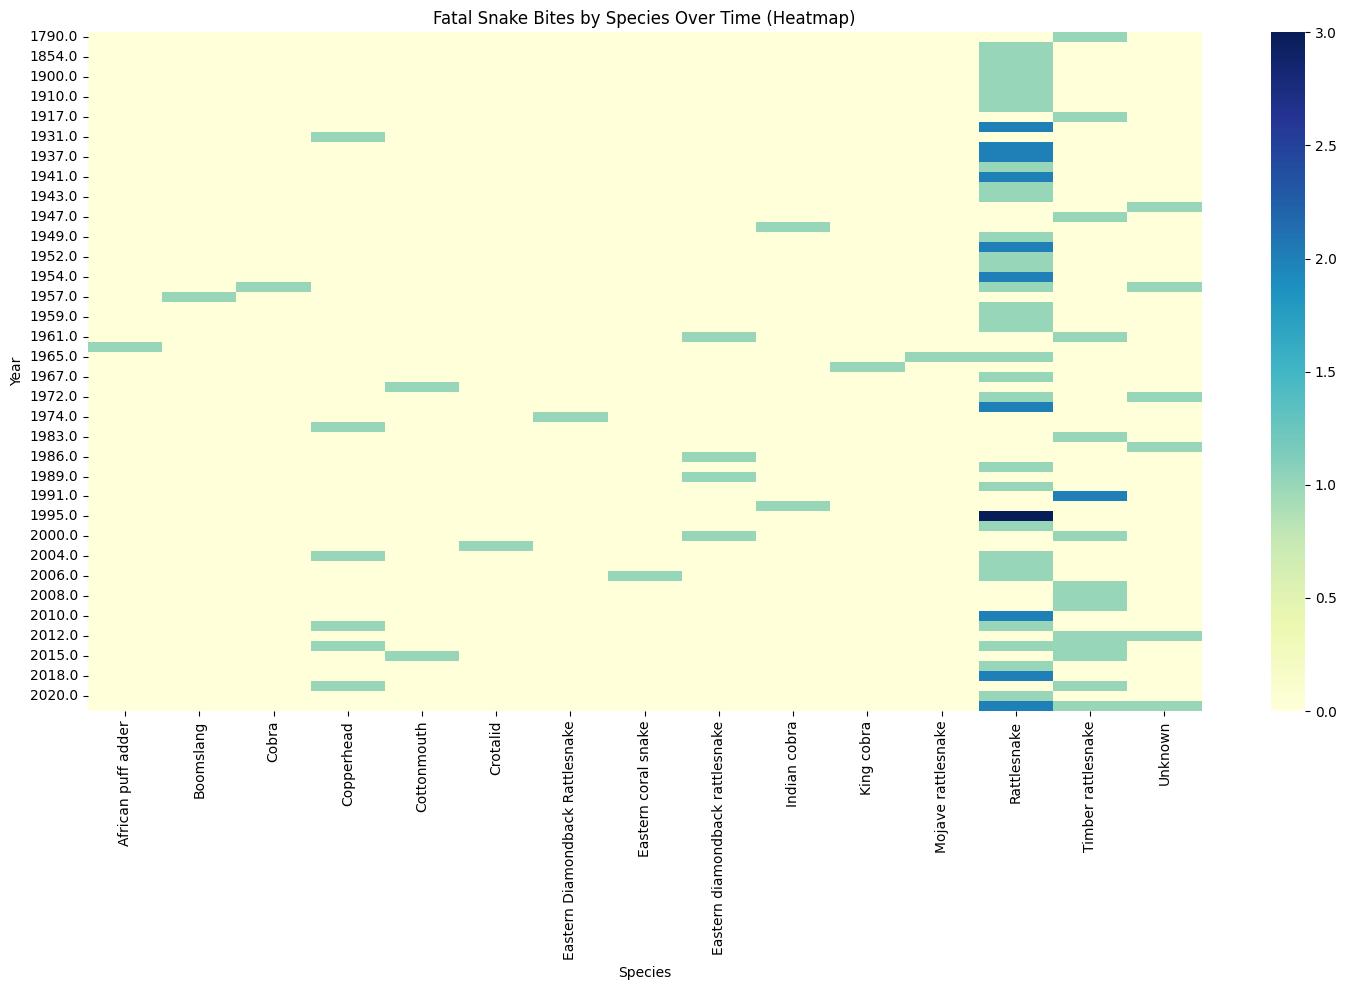

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

species_pivot_filtered = filtered_species_year_counts.pivot(index='Year', columns='Species', values='Count').fillna(0)

plt.figure(figsize=(15, 10))
sns.heatmap(species_pivot_filtered, cmap="YlGnBu")

plt.title('Fatal Snake Bites by Species Over Time (Heatmap)')
plt.xlabel('Species')
plt.ylabel('Year')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Visualization of the relation of Fatal Snake bites between species and the location

In [ ]:
location_species_counts = df.groupby(['Location', 'Species']).size().reset_index(name='Count')
display(location_species_counts.head())

,Location,Species,Count
0,Alabama,Copperhead,2
1,Alabama,Rattlesnake,2
2,"Alabama, Salem","Rattlesnake (probably eastern diamondback, but...",1
3,"Alabama, Winston County",Copperhead,1
4,Arizona,Mojave rattlesnake,1


In [ ]:
num_locations = location_species_counts['Location'].nunique()
num_species = location_species_counts['Species'].nunique()

print(f"Number of unique locations: {num_locations}")
print(f"Number of unique species: {num_species}")

if num_locations > 15:
    location_counts = location_species_counts.groupby('Location')['Count'].sum().sort_values(ascending=False)
    top_locations = location_counts.head(15).index.tolist()
    filtered_location_species_counts = location_species_counts[location_species_counts['Location'].isin(top_locations)].copy()
else:
    filtered_location_species_counts = location_species_counts.copy()

if num_species > 15:
    species_counts = filtered_location_species_counts.groupby('Species')['Count'].sum().sort_values(ascending=False)
    top_species = species_counts.head(15).index.tolist()
    filtered_location_species_counts = filtered_location_species_counts[filtered_location_species_counts['Species'].isin(top_species)].copy()

display(filtered_location_species_counts.head())

Number of unique locations: 42
Number of unique species: 29


,Location,Species,Count
0,Alabama,Copperhead,2
1,Alabama,Rattlesnake,2
4,Arizona,Mojave rattlesnake,1
5,Arizona,Rattlesnake,1
7,California,Indian cobra,1


In [ ]:
location_species_counts = df.groupby(['Location', 'Species']).size().reset_index(name='Count')
display(location_species_counts.head())

,Location,Species,Count
0,Alabama,Copperhead,2
1,Alabama,Rattlesnake,2
2,"Alabama, Salem","Rattlesnake (probably eastern diamondback, but...",1
3,"Alabama, Winston County",Copperhead,1
4,Arizona,Mojave rattlesnake,1


## Visualize the data

### Subtask:
Create a heatmap or another suitable plot to visualize the counts of snake bites by species for different locations.


**Reasoning**:
Pivot the filtered data and create the heatmap with appropriate labels and title.



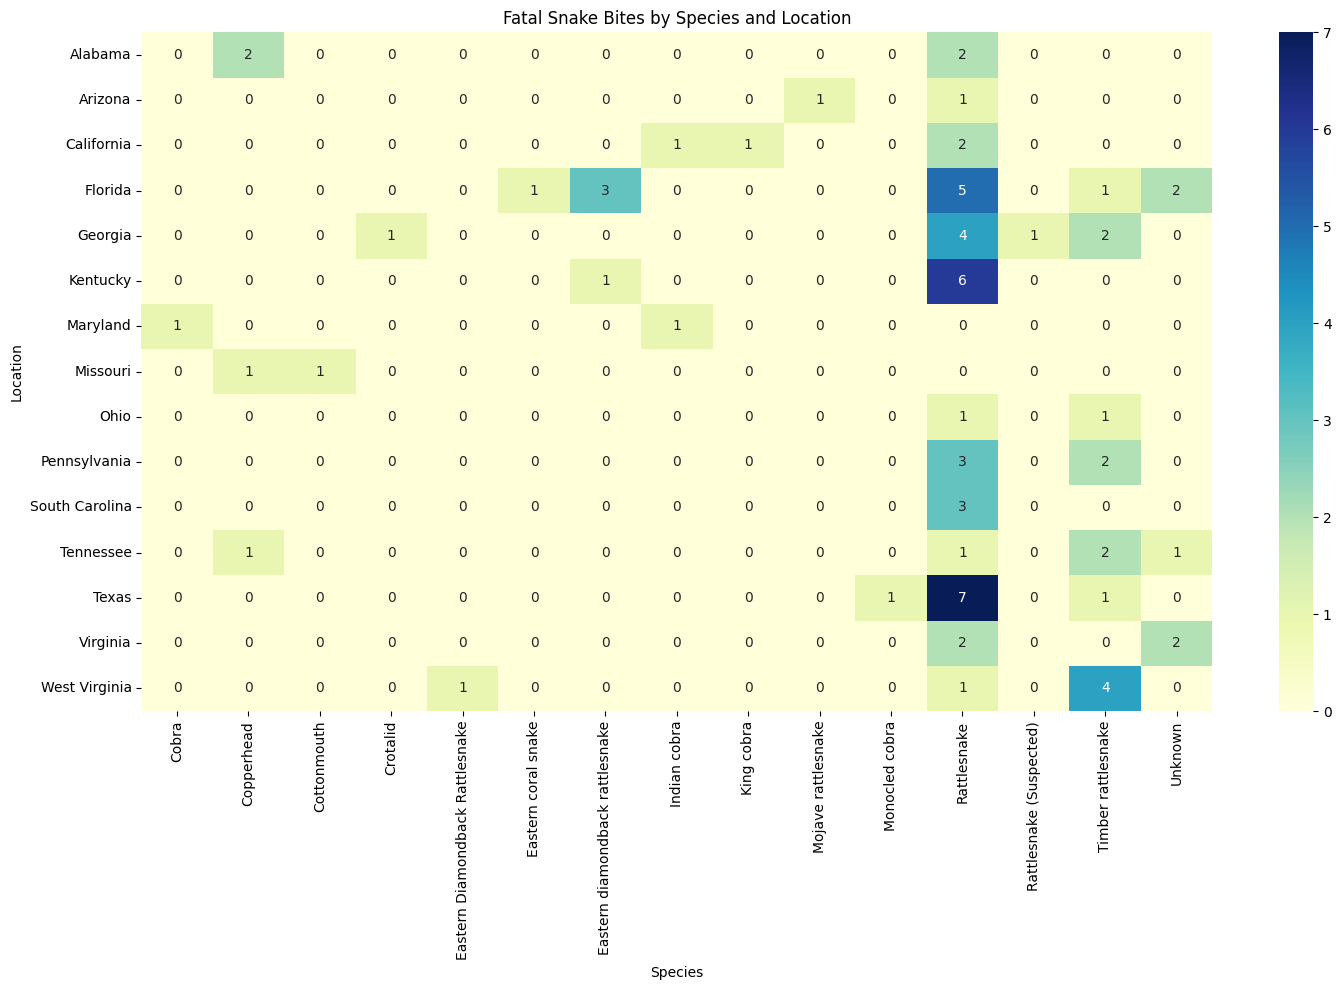

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

location_species_pivot_filtered = filtered_location_species_counts.pivot(index='Location', columns='Species', values='Count').fillna(0)

plt.figure(figsize=(15, 10))
sns.heatmap(location_species_pivot_filtered, cmap="YlGnBu", annot=True, fmt=".0f")

plt.title('Fatal Snake Bites by Species and Location')
plt.xlabel('Species')
plt.ylabel('Location')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Here are a few ways to create hyperlinks in Jupyter:

* **Standard Markdown link:**

  [Link text](URL "Title text")

  [Link to section](#section-title)

  https://www.google.com

  [![Alt text for image](Image URL)](Link URL)